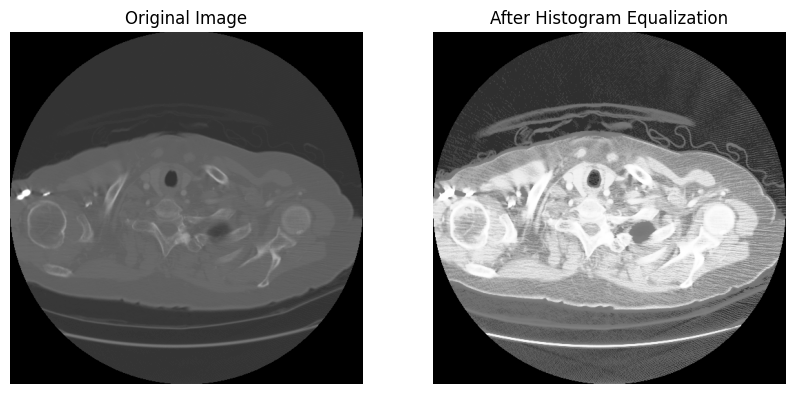

In [1]:
#Histogram Equalization enhancement#
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
ds = pydicom.dcmread("/kaggle/input/luna16-lung-cancer-dataset/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-008.dcm")
image = ds.pixel_array.astype(np.float32)
image_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# تطبيق HE
he_img = cv2.equalizeHist(image_8bit)

# عرض الصورة الأصلية + بعد HE
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_8bit, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(he_img, cmap='gray')
plt.title("After Histogram Equalization")
plt.axis('off')
plt.show()


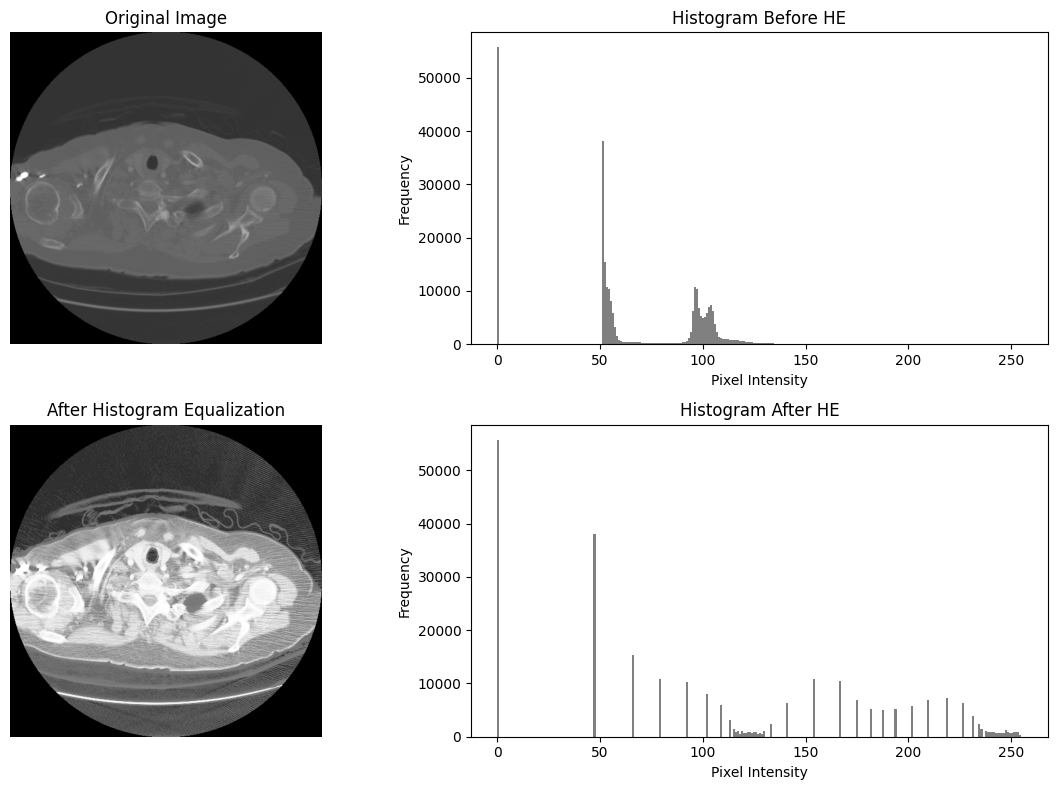

In [2]:
# Histogram Equalization enhancement
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
ds = pydicom.dcmread("/kaggle/input/luna16-lung-cancer-dataset/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-008.dcm")
image = ds.pixel_array.astype(np.float32)

# تحويل لـ 8bit
image_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# تطبيق HE
he_img = cv2.equalizeHist(image_8bit)

# عرض الصورة والهستوغرام
plt.figure(figsize=(12,8))

# Original Image
plt.subplot(2,2,1)
plt.imshow(image_8bit, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Histogram Before
plt.subplot(2,2,2)
plt.hist(image_8bit.ravel(), bins=256, color='gray')
plt.title("Histogram Before HE")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

# After HE Image
plt.subplot(2,2,3)
plt.imshow(he_img, cmap='gray')
plt.title("After Histogram Equalization")
plt.axis('off')

# Histogram After
plt.subplot(2,2,4)
plt.hist(he_img.ravel(), bins=256, color='gray')
plt.title("Histogram After HE")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


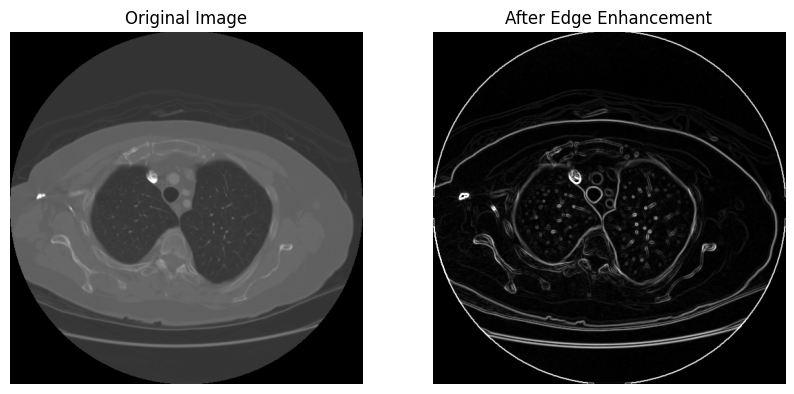

In [3]:
#Edge Enhancement#
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

# قراءة الصورة
ds = pydicom.dcmread("/kaggle/input/luna16-lung-cancer-dataset/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-023.dcm")
image = ds.pixel_array.astype(np.float32)
image_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# تطبيق Edge Enhancement
sobelx = cv2.Sobel(image_8bit, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(image_8bit, cv2.CV_64F, 0, 1, ksize=3)
edge_img = np.sqrt(sobelx**2 + sobely**2)
edge_img = np.clip(edge_img, 0, 255).astype(np.uint8)

# عرض الصورة الأصلية + بعد Edge Enhancement
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image_8bit, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edge_img, cmap='gray')
plt.title("After Edge Enhancement")
plt.axis('off')
plt.show()


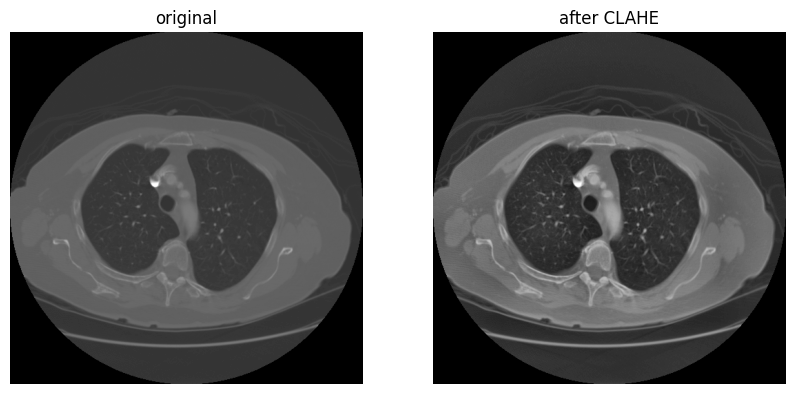

In [4]:
#CLAHE enhancement#
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# مسار الصورة الأصلية
image_path = "/kaggle/input/luna16-lung-cancer-dataset/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-029.dcm"  # عدلي بالمسار الصحيح
output_folder = "enhanced_images"
os.makedirs(output_folder, exist_ok=True)

# قراءة الصورة
ds = pydicom.dcmread(image_path)
image = ds.pixel_array.astype(np.float32)

# تحويل الصورة إلى 8-bit لتطبيق CLAHE
image_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# تطبيق CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced_img = clahe.apply(image_8bit)

# عرض الصورة قبل وبعد CLAHE
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_8bit, cmap='gray')
plt.title("original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(enhanced_img, cmap='gray')
plt.title("after CLAHE")
plt.axis('off')

plt.show()

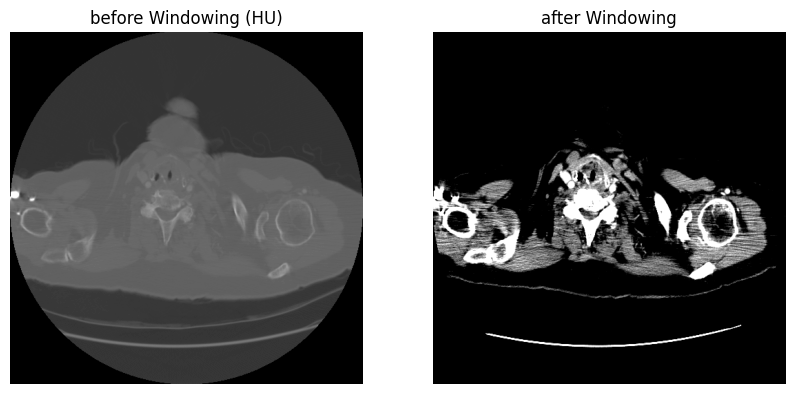

In [5]:
# hu & windowing enhancement #
import pydicom
import numpy as np
import matplotlib.pyplot as plt

# مسار الصورة
image_path = "/kaggle/input/luna16-lung-cancer-dataset/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/1-001.dcm"  # عدلي بالمسار الصحيح

# قراءة الصورة
ds = pydicom.dcmread(image_path)
image = ds.pixel_array.astype(np.float32)

# تحويل الصورة إلى Hounsfield Units (HU)
slope = ds.RescaleSlope
intercept = ds.RescaleIntercept
image_hu = image * slope + intercept

# دالة لتطبيق Windowing
def window_image(image_hu, window_center, window_width):
    min_hu = window_center - window_width / 2
    max_hu = window_center + window_width / 2
    windowed = np.clip(image_hu, min_hu, max_hu)
    windowed = ((windowed - min_hu) / (max_hu - min_hu) * 255).astype(np.uint8)
    return windowed

# تطبيق Windowing للنودل (-100 إلى +200 HU)
window_center = 50  # تقريبا منتصف النودل
window_width = 200
windowed_img = window_image(image_hu, window_center, window_width)

# عرض الصورة قبل وبعد Windowing
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_hu, cmap='gray')
plt.title("before Windowing (HU)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(windowed_img, cmap='gray')
plt.title("after Windowing")
plt.axis('off')

plt.show()

